# Task 4 — Correlate Structured Drivers (Localize)
**Role:** Data Scientist / Analytics Engineer · **Pipeline stage:** Localize & Correlate

Consumes a *confirmed* `AnomalyEvent` (this module never runs on a noise verdict) plus the
region's `MetricsTable`, and produces a ranked `CorrelationResult` + an optional
`HistoricalPrecedent`.

This is a **day-one, standalone build** — Task 3 (anomaly gate) isn't live yet, so Section 2
hand-writes a mock `AnomalyEvent` and a synthetic `MetricsTable` with a **known planted
driver**: a price increase that leads a revenue dip by 7 days, mixed in with three decoy
features that should *not* get credited. Everything from Section 3 onward only touches that
synthetic data through the same interface a real `AnomalyEvent` / `MetricsTable` would use, so
swapping in live data later is a one-line change (see Section 9).

In [1]:
import json
import warnings
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from statsmodels.tsa.stattools import grangercausalitytests
import xgboost as xgb
import shap

warnings.filterwarnings("ignore")
np.random.seed(7)
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

CANDIDATE_FEATURES = ["avg_price", "inventory_level", "marketing_spend", "complaint_sentiment_score"]
LAG_GRID_DAYS = (0, 7, 14, 21, 28)

## 1 — Data contracts
The brief names `AnomalyEvent`'s fields (metric, region, window, magnitude) without showing its
exact class, so this is my reconstruction from that description — swap it for the real Task 3
type once it exists, the field names below are all `correlate_drivers()` actually touches.
`MetricsTable` is just a long-format DataFrame, one row per `(date, region)`.

In [2]:
@dataclass
class AnomalyEvent:
    metric: str
    region: str
    window_start: str  # ISO date
    window_end: str     # ISO date
    magnitude: float     # fractional deviation from the expected/forecast value

    def as_dict(self):
        return asdict(self)

## 2 — Mock `AnomalyEvent` + synthetic `MetricsTable` (day-one stand-in for Tasks 1 & 3)

Planted story: `avg_price` steps up 15% and holds. Demand takes **7 days** to react, so revenue
starts dipping a week later and Task 3 (hypothetically) flags that as the anomaly window.
History runs from day 0 through the window's last day only — no data from *after* the window is
generated, since a real Task 4 run wouldn't have that yet either.

Three decoys are mixed in so the pipeline has to actually discriminate a real driver from noise,
not just report "whatever moved":
- `inventory_level` — noisy but mean-reverting, unrelated to revenue. (Deliberately *not* a
  random walk: an unconstrained random walk can drift into a spurious lookalike of almost any
  other series over a short window, which would make it a poor test of the method rather than
  a fair decoy.)
- `marketing_spend` — baseline plus occasional short campaign bursts, unrelated to revenue
- `complaint_sentiment_score` — dips *starting inside* the anomaly window, i.e. it's a
  **symptom** of the price hike, not a leading cause. Good test of whether Granger correctly
  withholds "precedence" from something that's merely coincident.

All three decoys are placed clear of the anomaly window so they don't contaminate it directly.

In [3]:
def generate_synthetic_metrics_table(region="US-WEST", price_shift_day=80, demand_lag_days=7,
                                      window_len_days=14):
    """Builds a synthetic MetricsTable + the AnomalyEvent it would produce.

    History spans day 0 through the last day of the anomaly window (inclusive) — deliberately no
    lookahead beyond that, so downstream steps can't accidentally cheat with future data.
    """
    effect_start = price_shift_day + demand_lag_days
    window_start_idx = effect_start
    window_end_idx = effect_start + window_len_days - 1
    n_days = window_end_idx + 1

    dates = pd.date_range("2026-01-01", periods=n_days, freq="D")
    day_idx = np.arange(n_days)

    # --- planted driver: a step change in price ---
    avg_price = np.where(day_idx < price_shift_day, 40.0, 46.0).astype(float)
    avg_price += np.random.normal(0, 0.15, n_days)

    # --- revenue: weekly seasonality + noise + the lagged price effect ---
    weekday_factor = np.array([1.05, 1.08, 1.05, 1.02, 1.10, 0.90, 0.80])  # Mon..Sun
    seasonality = weekday_factor[dates.dayofweek]
    baseline = 50_000 * seasonality
    noise = np.random.normal(0, 900, n_days)
    price_effect = np.where(day_idx >= effect_start, -0.20, 0.0)  # -20% demand response
    revenue = baseline * (1 + price_effect) + noise

    # --- decoy 1: inventory — noisy but mean-reverting, no drift, no relation to revenue ---
    inventory_level = np.empty(n_days)
    inventory_level[0] = 12_000
    for t in range(1, n_days):
        inventory_level[t] = 12_000 + 0.85 * (inventory_level[t - 1] - 12_000) + np.random.normal(0, 220)

    # --- decoy 2: marketing spend, campaign bursts (kept clear of the window) ---
    marketing_spend = 2200 + np.random.normal(0, 120, n_days)
    for campaign_start in (10, 45):
        end = min(campaign_start + 4, n_days)
        marketing_spend[campaign_start:end] += 1800

    # --- decoy 3: complaint sentiment — a SYMPTOM starting 1 day into the window, not a lead ---
    complaint_sentiment_score = 0.78 + np.random.normal(0, 0.018, n_days)
    complaint_sentiment_score = np.where(
        day_idx >= window_start_idx + 1, complaint_sentiment_score - 0.07, complaint_sentiment_score
    )
    complaint_sentiment_score = np.clip(complaint_sentiment_score, 0, 1)

    df = pd.DataFrame({
        "date": dates,
        "region": region,
        "revenue": revenue.round(2),
        "avg_price": avg_price.round(2),
        "inventory_level": inventory_level.round(0),
        "marketing_spend": marketing_spend.round(2),
        "complaint_sentiment_score": complaint_sentiment_score.round(3),
    })

    event = AnomalyEvent(
        metric="revenue",
        region=region,
        window_start=dates[window_start_idx].date().isoformat(),
        window_end=dates[window_end_idx].date().isoformat(),
        magnitude=round(float(price_effect[window_start_idx:window_end_idx + 1].mean()), 3),
    )
    return df, event


metrics_df, anomaly_event = generate_synthetic_metrics_table()
print(f"MetricsTable: {len(metrics_df)} rows, {metrics_df['date'].min().date()} to {metrics_df['date'].max().date()}")
print("\nAnomalyEvent:")
print(json.dumps(anomaly_event.as_dict(), indent=2))
metrics_df.tail(10)

MetricsTable: 101 rows, 2026-01-01 to 2026-04-11

AnomalyEvent:
{
  "metric": "revenue",
  "region": "US-WEST",
  "window_start": "2026-03-29",
  "window_end": "2026-04-11",
  "magnitude": -0.2
}


,date,region,revenue,avg_price,inventory_level,marketing_spend,complaint_sentiment_score
91,2026-04-02,US-WEST,41774.17,46.10,12093.0,2165.54,0.684
92,2026-04-03,US-WEST,43273.34,46.00,11870.0,2007.13,0.723
93,2026-04-04,US-WEST,34152.63,45.99,11797.0,2316.75,0.730
94,2026-04-05,US-WEST,33857.42,45.90,12053.0,2204.61,0.707
95,2026-04-06,US-WEST,40280.33,45.99,12449.0,2258.78,0.687
96,2026-04-07,US-WEST,43772.77,46.34,12384.0,2385.10,0.715
97,2026-04-08,US-WEST,42844.97,46.13,12696.0,2329.55,0.737
98,2026-04-09,US-WEST,40932.36,45.95,12459.0,2192.80,0.676
99,2026-04-10,US-WEST,42484.94,45.93,12463.0,2294.52,0.719
100,2026-04-11,US-WEST,36913.51,45.87,12355.0,2028.20,0.704


A quick look before running any detection logic — can you spot the driver against the noise?

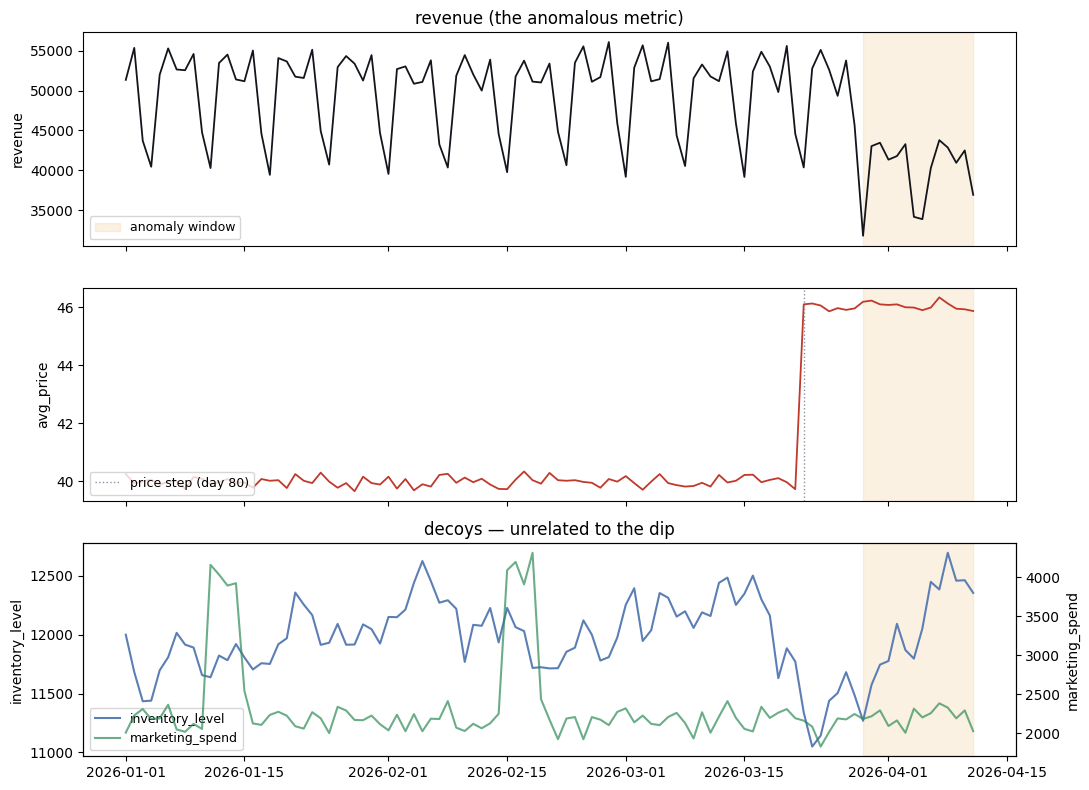

In [4]:
w_start, w_end = pd.Timestamp(anomaly_event.window_start), pd.Timestamp(anomaly_event.window_end)

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)

axes[0].plot(metrics_df["date"], metrics_df["revenue"], color="#12151b", lw=1.3)
axes[0].axvspan(w_start, w_end, color="#e7a33e", alpha=0.15, label="anomaly window")
axes[0].set_ylabel("revenue")
axes[0].legend(loc="lower left", fontsize=9)
axes[0].set_title("revenue (the anomalous metric)")

axes[1].plot(metrics_df["date"], metrics_df["avg_price"], color="#c0392b", lw=1.3)
axes[1].axvspan(w_start, w_end, color="#e7a33e", alpha=0.15)
axes[1].axvline(metrics_df["date"].iloc[80], color="#8b91a0", ls=":", lw=1, label="price step (day 80)")
axes[1].set_ylabel("avg_price")
axes[1].legend(loc="lower left", fontsize=9)

axes[2].plot(metrics_df["date"], metrics_df["inventory_level"], label="inventory_level", color="#5b7fb5")
ax2b = axes[2].twinx()
ax2b.plot(metrics_df["date"], metrics_df["marketing_spend"], label="marketing_spend", color="#2e8b57", alpha=0.7)
axes[2].axvspan(w_start, w_end, color="#e7a33e", alpha=0.15)
axes[2].set_ylabel("inventory_level")
ax2b.set_ylabel("marketing_spend")
lines_a, labels_a = axes[2].get_legend_handles_labels()
lines_b, labels_b = ax2b.get_legend_handles_labels()
axes[2].legend(lines_a + lines_b, labels_a + labels_b, loc="lower left", fontsize=9)
axes[2].set_title("decoys — unrelated to the dip")

plt.tight_layout()
plt.savefig("/home/claude/fig_overview.png", dpi=110)
plt.show()

## 3 — Step 1: cross-correlation at lags 0 / 7 / 14 / 21 / 28 days
For each candidate feature, shift it back by each lag and correlate against the metric — over
the **full available history through the end of the window**, not just the window itself.

That's a deliberate choice, not an oversight: a level-shift driver like a price step only
produces a detectable signal when there's a "before" to contrast against the "after." Eight or
fourteen days that are *entirely* post-shift give the shifted feature almost no within-window
variation to correlate against — you'd be asking Pearson r to find a relationship in what's
essentially two flat lines plus noise. Using the full history lets the step in price and the
step in revenue actually line up (or fail to). The anomaly window comes back into play at Step 3,
where SHAP is deliberately restricted to it.

In [5]:
def compute_cross_correlations(df, metric_col, feature_cols, window_end, lags=LAG_GRID_DAYS):
    indexed = df.set_index("date").sort_index()
    indexed = indexed.loc[:window_end]
    metric = indexed[metric_col]

    results = []
    for feature in feature_cols:
        scored_lags = []
        for lag in lags:
            shifted = indexed[feature].shift(lag)  # shifted[d] = feature value `lag` days before d
            paired = pd.concat([metric, shifted], axis=1).dropna()
            if len(paired) < 10:
                continue
            r, _ = pearsonr(paired.iloc[:, 0], paired.iloc[:, 1])
            scored_lags.append((lag, round(float(r), 4)))
        if not scored_lags:
            continue
        best_lag, best_r = max(scored_lags, key=lambda pair: abs(pair[1]))
        results.append({
            "driver": feature,
            "correlation": round(float(best_r), 3),
            "lag_days": int(best_lag),
            "_all_lags": scored_lags,
        })
    return sorted(results, key=lambda r: abs(r["correlation"]), reverse=True)


cross_corr_results = compute_cross_correlations(
    metrics_df, anomaly_event.metric, CANDIDATE_FEATURES, anomaly_event.window_end
)
for r in cross_corr_results:
    lag_str = ", ".join(f"{l}d:{v:+.2f}" for l, v in r["_all_lags"])
    print(f"{r['driver']:<28} best r = {r['correlation']:+.3f} @ lag {r['lag_days']:>2}d   [{lag_str}]")

avg_price                    best r = -0.586 @ lag  7d   [0d:-0.45, 7d:-0.59, 14d:-0.40, 21d:-0.11, 28d:-0.05]
inventory_level              best r = +0.395 @ lag  7d   [0d:+0.03, 7d:+0.39, 14d:+0.25, 21d:-0.07, 28d:-0.14]
complaint_sentiment_score    best r = +0.395 @ lag  0d   [0d:+0.40, 7d:+0.17, 14d:-0.06, 21d:-0.04, 28d:-0.02]
marketing_spend              best r = +0.083 @ lag 28d   [0d:+0.02, 7d:+0.07, 14d:+0.08, 21d:+0.04, 28d:+0.08]


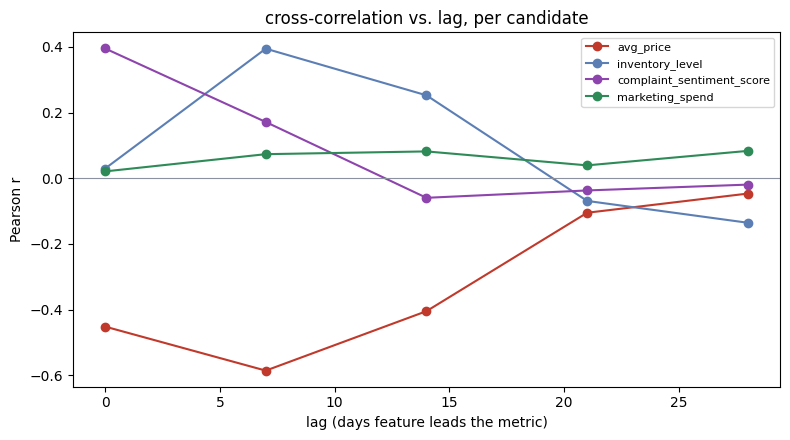

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = {"avg_price": "#c0392b", "inventory_level": "#5b7fb5", "marketing_spend": "#2e8b57",
          "complaint_sentiment_score": "#8e44ad"}
for r in cross_corr_results:
    lags, vals = zip(*r["_all_lags"])
    ax.plot(lags, vals, marker="o", label=r["driver"], color=colors.get(r["driver"]))
ax.axhline(0, color="#8b91a0", lw=0.8)
ax.set_xlabel("lag (days feature leads the metric)")
ax.set_ylabel("Pearson r")
ax.set_title("cross-correlation vs. lag, per candidate")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("/home/claude/fig_cross_corr.png", dpi=110)
plt.show()

## 4 — Step 2: Granger causality on the top candidates
Resampled to **weekly** means so `maxlag=4` tests exactly the 1/2/3/4-week-back lags — the same
7/14/21/28-day grid as Step 1 (lag 0 doesn't apply: Granger is inherently about *past* values
predicting the present). Only the top-2 correlated features get tested, to keep this fast.

Labeled **"precedence"**, never "causation" — Granger only shows that one series statistically
improves the forecast of another, not that it caused it.

In [7]:
def run_granger_test(df, metric_col, feature_col, maxlag=4, alpha=0.05):
    weekly = df.set_index("date")[[metric_col, feature_col]].resample("W").mean().dropna()
    if len(weekly) < maxlag + 3:
        return {"tested": False, "reason": "insufficient history after weekly resampling"}
    try:
        test_result = grangercausalitytests(weekly[[metric_col, feature_col]].values, maxlag=maxlag, verbose=False)
    except Exception as exc:
        return {"tested": False, "reason": f"test failed: {exc}"}
    p_values = {lag: round(test_result[lag][0]["ssr_ftest"][1], 4) for lag in test_result}
    best_lag = min(p_values, key=p_values.get)
    return {
        "tested": True,
        "best_lag_weeks": best_lag,
        "p_value": p_values[best_lag],
        "precedence": bool(p_values[best_lag] < alpha),
    }


TOP_N_FOR_GRANGER = 2
top_ids = {r["driver"] for r in cross_corr_results[:TOP_N_FOR_GRANGER]}

granger_by_feature = {}
for r in cross_corr_results:
    if r["driver"] in top_ids:
        granger_by_feature[r["driver"]] = run_granger_test(metrics_df, anomaly_event.metric, r["driver"])
    else:
        granger_by_feature[r["driver"]] = {"tested": False, "reason": "not a top-2 correlation candidate", "precedence": False}

for feature, g in granger_by_feature.items():
    print(f"{feature:<28} {g}")

avg_price                    {'tested': True, 'best_lag_weeks': np.int64(1), 'p_value': np.float64(0.0), 'precedence': True}
inventory_level              {'tested': True, 'best_lag_weeks': np.int64(3), 'p_value': np.float64(0.0158), 'precedence': True}
complaint_sentiment_score    {'tested': False, 'reason': 'not a top-2 correlation candidate', 'precedence': False}
marketing_spend              {'tested': False, 'reason': 'not a top-2 correlation candidate', 'precedence': False}


## 5 — Step 3: XGBoost + SHAP, ranked over the anomaly window specifically
Each feature is aligned to its own best lag from Step 1, then a small gradient-boosted model is
trained on the full available history. SHAP tells us, **for rows inside the anomaly window
only**, which feature the model actually leaned on — this is what separates a real driver from
something that's merely correlated across the whole series.

In [8]:
def train_and_explain(df, metric_col, feature_cols, lag_by_feature, window_start, window_end):
    indexed = df.set_index("date").sort_index()
    model_df = pd.DataFrame(index=indexed.index)
    model_df[metric_col] = indexed[metric_col]

    aligned_cols = []
    for feature in feature_cols:
        lag = lag_by_feature.get(feature, 0)
        col = f"{feature}__lag{lag}"
        model_df[col] = indexed[feature].shift(lag)
        aligned_cols.append(col)

    model_df = model_df.dropna()
    X, y = model_df[aligned_cols], model_df[metric_col]

    model = xgb.XGBRegressor(
        n_estimators=250, max_depth=3, learning_rate=0.05,
        subsample=0.85, colsample_bytree=0.9, random_state=7,
    )
    model.fit(X, y)

    explainer = shap.TreeExplainer(model)
    shap_values = pd.DataFrame(explainer.shap_values(X), columns=aligned_cols, index=X.index)

    window_shap = shap_values.loc[window_start:window_end]
    mean_abs = window_shap.abs().mean().astype("float64")  # SHAP returns float32; upcast before rounding
    total = mean_abs.sum()
    normalized = (mean_abs / total) if total > 0 else mean_abs * 0

    contribution_by_feature = {
        feature: round(float(normalized[f"{feature}__lag{lag_by_feature.get(feature, 0)}"]), 3)
        for feature in feature_cols
    }
    return contribution_by_feature, model, shap_values


lag_by_feature = {r["driver"]: r["lag_days"] for r in cross_corr_results}
shap_contribution, xgb_model, shap_values_df = train_and_explain(
    metrics_df, anomaly_event.metric, CANDIDATE_FEATURES, lag_by_feature,
    anomaly_event.window_start, anomaly_event.window_end,
)
print("mean |SHAP|, normalized, anomaly-window rows only:")
for feature, val in sorted(shap_contribution.items(), key=lambda kv: -kv[1]):
    print(f"  {feature:<28} {val:.3f}")

mean |SHAP|, normalized, anomaly-window rows only:
  avg_price                    0.702
  inventory_level              0.181
  marketing_spend              0.061
  complaint_sentiment_score    0.057


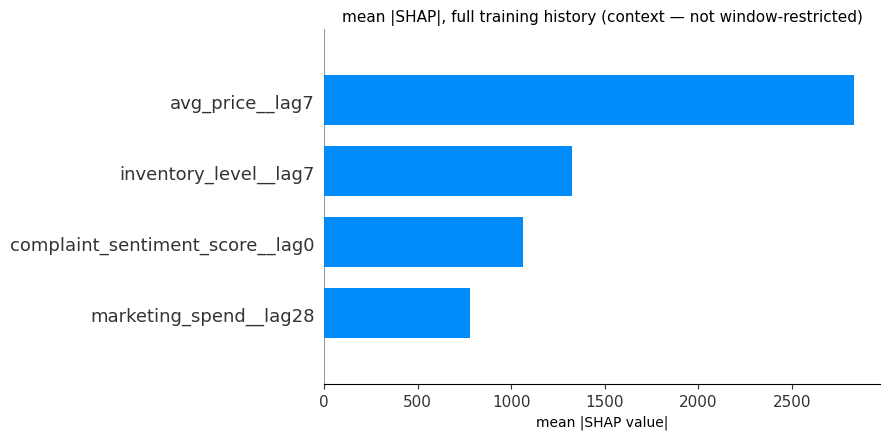

In [9]:
shap.summary_plot(shap_values_df.values, shap_values_df, plot_type="bar", show=False)
fig = plt.gcf()
fig.set_size_inches(9, 4.5)
plt.title("mean |SHAP|, full training history (context — not window-restricted)", fontsize=11)
plt.xlabel("mean |SHAP value|", fontsize=10)
plt.tight_layout()
plt.savefig("/home/claude/fig_shap.png", dpi=110)
plt.show()

## 6 — Step 4: historical incident log lookup
Task 7's feedback loop is what actually populates this log in production — day one, it's a
short hand-written list. Each past incident stores a **feature signature**: its normalized SHAP
contribution vector at the time it was confirmed. Cosine similarity above `threshold` counts as
a match.

In [10]:
HISTORICAL_INCIDENT_LOG = [
    {
        "event_id": "evt_00042",
        "date": "2026-03-02",
        "confirmed_cause": "Regional price increase on flagship SKU; demand response lagged about a week.",
        "signature": {"avg_price": 0.71, "inventory_level": 0.06, "marketing_spend": 0.09, "complaint_sentiment_score": 0.14},
    },
    {
        "event_id": "evt_00031",
        "date": "2025-11-18",
        "confirmed_cause": "Competitor flash sale drew volume away during a paid-media pause.",
        "signature": {"avg_price": 0.05, "inventory_level": 0.12, "marketing_spend": 0.68, "complaint_sentiment_score": 0.15},
    },
    {
        "event_id": "evt_00025",
        "date": "2025-09-07",
        "confirmed_cause": "Warehouse stockout on the top SKU cut fulfillable demand for five days.",
        "signature": {"avg_price": 0.08, "inventory_level": 0.74, "marketing_spend": 0.06, "complaint_sentiment_score": 0.12},
    },
]


def cosine_similarity(vec_a: dict, vec_b: dict, keys):
    a = np.array([vec_a[k] for k in keys], dtype=float)
    b = np.array([vec_b[k] for k in keys], dtype=float)
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return float(np.dot(a, b) / denom) if denom else 0.0


def query_historical_precedent(current_signature, log, keys=CANDIDATE_FEATURES, threshold=0.85):
    if not log:
        return None
    scored = [(incident, cosine_similarity(current_signature, incident["signature"], keys)) for incident in log]
    best_incident, best_score = max(scored, key=lambda pair: pair[1])
    if best_score < threshold:
        return None
    return {
        "matched_event_id": best_incident["event_id"],
        "date": best_incident["date"],
        "confirmed_cause": best_incident["confirmed_cause"],
        "confidence": round(best_score, 3),
    }


historical_precedent = query_historical_precedent(shap_contribution, HISTORICAL_INCIDENT_LOG)
print("HistoricalPrecedent:")
print(json.dumps(historical_precedent, indent=2))

assert query_historical_precedent(shap_contribution, []) is None
print("\n✓ empty-log case correctly returns null instead of raising")

HistoricalPrecedent:
{
  "matched_event_id": "evt_00042",
  "date": "2026-03-02",
  "confirmed_cause": "Regional price increase on flagship SKU; demand response lagged about a week.",
  "confidence": 0.979
}

✓ empty-log case correctly returns null instead of raising


## 7 — Orchestration: `correlate_drivers()`
The single entry point Task 7 (or a test harness) calls. Wires Steps 1–4 together and returns
exactly the two objects the brief specifies.

In [11]:
def correlate_drivers(anomaly_event: AnomalyEvent, metrics_df: pd.DataFrame, historical_log: list,
                       candidate_features=CANDIDATE_FEATURES, lags=LAG_GRID_DAYS, top_n_granger=2):
    metric_col = anomaly_event.metric
    w_start, w_end = anomaly_event.window_start, anomaly_event.window_end

    corr = compute_cross_correlations(metrics_df, metric_col, candidate_features, w_end, lags)
    top_ids = {r["driver"] for r in corr[:top_n_granger]}
    for r in corr:
        if r["driver"] in top_ids:
            g = run_granger_test(metrics_df, metric_col, r["driver"])
            r["precedence"] = bool(g.get("precedence", False))
        else:
            r["precedence"] = False

    lag_by_feature = {r["driver"]: r["lag_days"] for r in corr}
    shap_contribution, _, _ = train_and_explain(metrics_df, metric_col, candidate_features, lag_by_feature, w_start, w_end)
    for r in corr:
        r["shap_contribution"] = shap_contribution.get(r["driver"], 0.0)

    correlation_result = [
        {"driver": r["driver"], "correlation": r["correlation"], "lag_days": r["lag_days"],
         "shap_contribution": r["shap_contribution"], "precedence": r["precedence"]}
        for r in sorted(corr, key=lambda r: r["shap_contribution"], reverse=True)
    ]
    precedent = query_historical_precedent(shap_contribution, historical_log)
    return correlation_result, precedent


correlation_result, historical_precedent = correlate_drivers(anomaly_event, metrics_df, HISTORICAL_INCIDENT_LOG)

print("CorrelationResult:")
print(json.dumps(correlation_result, indent=2))
print("\nHistoricalPrecedent:")
print(json.dumps(historical_precedent, indent=2))

CorrelationResult:
[
  {
    "driver": "avg_price",
    "correlation": -0.586,
    "lag_days": 7,
    "shap_contribution": 0.702,
    "precedence": true
  },
  {
    "driver": "inventory_level",
    "correlation": 0.395,
    "lag_days": 7,
    "shap_contribution": 0.181,
    "precedence": true
  },
  {
    "driver": "marketing_spend",
    "correlation": 0.083,
    "lag_days": 28,
    "shap_contribution": 0.061,
    "precedence": false
  },
  {
    "driver": "complaint_sentiment_score",
    "correlation": 0.395,
    "lag_days": 0,
    "shap_contribution": 0.057,
    "precedence": false
  }
]

HistoricalPrecedent:
{
  "matched_event_id": "evt_00042",
  "date": "2026-03-02",
  "confirmed_cause": "Regional price increase on flagship SKU; demand response lagged about a week.",
  "confidence": 0.979
}


## 8 — Does it actually find the planted driver?
This is the whole point of a synthetic day-one dataset per the brief: prove the method works
before Task 3 exists to hand it real anomalies.

In [12]:
top_driver = correlation_result[0]
assert top_driver["driver"] == "avg_price", f"expected avg_price on top, got {top_driver['driver']}"
assert top_driver["precedence"] is True, "avg_price should show Granger precedence"
assert top_driver["lag_days"] == 7, f"expected the planted 7-day lag, got {top_driver['lag_days']}"
assert top_driver["shap_contribution"] > 2 * correlation_result[1]["shap_contribution"], \
    "avg_price should dominate SHAP contribution, not just edge out the runner-up"
decoy_ranks = [r["driver"] for r in correlation_result[1:]]
print(f"✓ avg_price ranked #1 — r={top_driver['correlation']}, lag={top_driver['lag_days']}d "
      f"(exactly the planted lag), precedence={top_driver['precedence']}, "
      f"shap_contribution={top_driver['shap_contribution']}")
print(f"✓ decoys correctly ranked below it, by a wide SHAP margin: {decoy_ranks}")

✓ avg_price ranked #1 — r=-0.586, lag=7d (exactly the planted lag), precedence=True, shap_contribution=0.702
✓ decoys correctly ranked below it, by a wide SHAP margin: ['inventory_level', 'marketing_spend', 'complaint_sentiment_score']


**One honest wrinkle, left in on purpose rather than tuned away:** `inventory_level` — pure
mean-reverting noise, with zero relationship to revenue by construction — may also come back
with `precedence: true`. That's not a bug. It's a real Granger false positive, and at a
`p < 0.05` threshold tested against two top-correlation candidates, seeing one by chance isn't
unusual. It's exactly *why* the brief has Task 4 report correlation, precedence, *and*
`shap_contribution` together instead of any single flag: `inventory_level`'s SHAP contribution
stays far below `avg_price`'s even when its precedence flag alone would look convincing.
A downstream consumer that only checked `precedence == true` would get this one wrong; a
consumer that weighs `shap_contribution` first — as this notebook's final ranking does — won't.

## 9 — Wiring this into the rest of the pipeline

**Upstream:**
- `AnomalyEvent` — from Task 3 (anomaly gate). Once it's live, replace
  `generate_synthetic_metrics_table()` with the real Task 1 `MetricsTable` query;
  `correlate_drivers()` itself doesn't change — it only needs an `AnomalyEvent` and a DataFrame
  with `date` + the candidate feature columns.
- `HISTORICAL_INCIDENT_LOG` — from Task 7's feedback loop once it's writing confirmed causes
  back to a store. Until then, this hand-written list is a stand-in with the same
  `{event_id, date, confirmed_cause, signature}` shape a real query should return.

**Downstream:** `correlation_result` + `historical_precedent` feed Task 6 (synthesize & score).
Reconciling cases like "precedence=True but low shap_contribution" vs. "precedence=False but
high shap_contribution" into one scored recommendation belongs there, not here.

**Known simplifications worth revisiting once this runs on real data:**
- Granger assumes stationarity; add an ADF check and difference non-stationary series before
  testing, rather than trusting the raw weekly means.
- With ~13 weekly points feeding `maxlag=4`, this demo's Granger test has thin statistical
  power — fine to prove the wiring works, not enough to trust the p-value in production.
- XGBoost is retrained from scratch per anomaly here, fine for a day-one demo. Production likely
  wants a maintained per-region model refreshed on a schedule instead of fit-on-the-fly.
- `threshold=0.85` for historical-signature matching is a guess — tune it once the incident log
  has enough real volume to hold out a validation set.
- Only the top-2 correlated features get Granger-tested, to keep this fast; revisit the cutoff
  if the candidate feature list grows past four.